# BBN abundance evolution

Plots $A_i Y_i(t)$ for each nuclide vs cosmic time, for the **small** (12-reaction,
8-nuclide), **medium** (62-reaction, 12-nuclide) and **large** (~433-reaction,
~59-nuclide) networks, with a secondary axis showing $T_\gamma$ in MeV.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from pyprimat.main import PyPR

In [2]:
def add_temperature_axis(ax, instance, T_ticks_MeV):
    """Add a top x-axis showing T_gamma in MeV."""
    t_ticks = [float(instance.t_of_T(T)) for T in T_ticks_MeV]
    ax2 = ax.twiny()
    ax2.set_xscale('log')
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(t_ticks)
    ax2.set_xticklabels([str(T) for T in T_ticks_MeV])
    ax2.set_xlabel(r'$T_\gamma$ [MeV]')
    return ax2

t = np.logspace(0, 6, 500)   # 1 s to 1e10 s
T_ticks_MeV = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01]

## Small network (12 reactions, 8 nuclides)

In [3]:
r_small = PyPR({'network': 'small', 'verbose': True})


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 ┃
┃   ░█▀█░█░█░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀              ┃
┃   ░█▀▀░░█░░█▀▀░█▀▄░░█░░█░█░█▀█░░█░              ┃
┃   ░▀░░░░▀░░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░              ┃
┃                                                 ┃
┃    Welcome to PyPRIMAT v0.1.0 — Cyril Pitrou    ┃
┃                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[init]  numba detected: using it for JIT compilation.
[init]  Electron-thermo tables loaded from cache (2000 points).
[init]  Tables loaded.
[rates] Building 'small' network from text lists.
[rates] MT network: 12 reactions over 8 nuclides.
[rates] LT network: 12 reactions over 8 nuclides.
------------------------------------------------------------
Loaded 13 reactions (LT network):
------------------------------------------------------------
  n <-> p                 [weak n<->p]
  n + p <-> H2            [And06]
  H2 + p <

[nucl]  Solving neutron decoupling at high temperature era
[nucl]  [HT] Finished solve_ivp in 0.07 s (status=0, nfev=3332)
[nucl]  Solving nuclear network at mid temperature era
[nucl]  [MT] Finished solve_ivp (small network, 8 species) in 0.58 s (status=0, nfev=7416)
[nucl]  Solving nuclear network at low temperature era
[nucl]  [LT] Finished solve_ivp (small network, 8 nuclides) in 0.77 s (status=0, nfev=12838)
--------------------------------------------------
Predicted primordial abundances at the end of BBN (8 numerically solved nuclides)
--------------------------------------------------
  Yn    = 4.024165e-16
  Yp    = 7.529445e-01
  YH2   = 1.833371e-05
  YH3   = 5.849702e-08
  YHe3  = 7.770359e-06
  YHe4  = 6.174884e-02
  YLi7  = 2.180860e-11
  YBe7  = 3.969565e-10


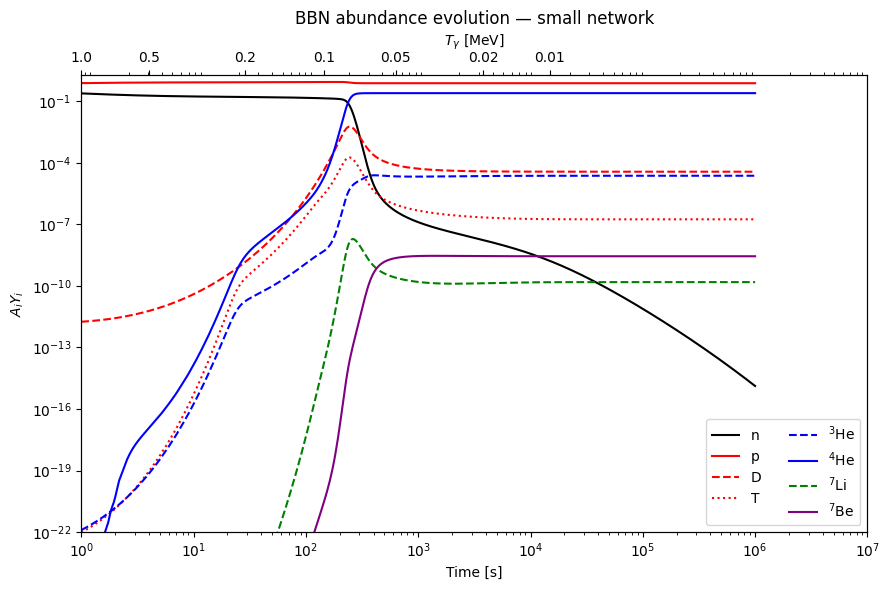

In [4]:
# (species key, color, linestyle, legend label)
species_small = [
    ('n',   'black',  'solid',  'n'),
    ('p',   'red',    'solid',  'p'),
    ('H2',  'red',    'dashed', 'D'),
    ('H3',  'red',    'dotted', 'T'),
    ('He3', 'blue',   'dashed', r'$^3$He'),
    ('He4', 'blue',   'solid',  r'$^4$He'),
    ('Li7', 'green',  'dashed', r'$^7$Li'),
    ('Be7', 'purple', 'solid',  r'$^7$Be'),
]

fig, ax = plt.subplots(figsize=(9, 6))

for name, color, ls, label in species_small:
    vals = r_small.A[name] * r_small[name](t)
    mask = vals > 0
    if mask.any():
        ax.plot(t[mask], vals[mask], color=color, ls=ls, label=label)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$A_i Y_i$')
ax.set_xlim(1, 1e7)
ax.set_ylim(1e-22, 2)
ax.legend(ncol=2)
ax.set_title('BBN abundance evolution — small network')
add_temperature_axis(ax, r_small, T_ticks_MeV)

plt.tight_layout()
plt.savefig('plots/abundance_evolution_small.pdf', bbox_inches='tight')
plt.show()

## Medium network (62 reactions, 12 nuclides)

In [5]:
r_medium = PyPR({'network': 'medium', 'verbose': True})


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 ┃
┃   ░█▀█░█░█░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀              ┃
┃   ░█▀▀░░█░░█▀▀░█▀▄░░█░░█░█░█▀█░░█░              ┃
┃   ░▀░░░░▀░░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░              ┃
┃                                                 ┃
┃    Welcome to PyPRIMAT v0.1.0 — Cyril Pitrou    ┃
┃                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[init]  numba detected: using it for JIT compilation.
[init]  Electron-thermo tables loaded from cache (2000 points).
[init]  Tables loaded.
[rates] Building 'medium' network from text lists.
[rates] MT network: 17 reactions over 12 nuclides.
[rates] LT network: 62 reactions over 12 nuclides.
------------------------------------------------------------
Loaded 63 reactions (LT network):
------------------------------------------------------------
  n <-> p                           [weak n<->p]
  n + p <-> H2                 

[nucl]  Solving neutron decoupling at high temperature era
[nucl]  [HT] Finished solve_ivp in 0.09 s (status=0, nfev=3332)
[nucl]  Solving nuclear network at mid temperature era
[nucl]  [MT] Finished solve_ivp (medium network, 12 species) in 0.50 s (status=0, nfev=7177)
[nucl]  Solving nuclear network at low temperature era
[nucl]  [LT] Finished solve_ivp (medium network, 12 nuclides) in 0.88 s (status=0, nfev=13349)
--------------------------------------------------
Predicted primordial abundances at the end of BBN (12 numerically solved nuclides)
--------------------------------------------------
  Yn    = 4.026099e-16
  Yp    = 7.529421e-01
  YH2   = 1.833873e-05
  YH3   = 5.850344e-08
  YHe3  = 7.768827e-06
  YHe4  = 6.174943e-02
  YLi7  = 2.139428e-11
  YBe7  = 3.932388e-10
  YHe6  = 9.045159e-31
  YLi8  = 6.568987e-20
  YLi6  = 5.875861e-15
  YB8   = 2.432445e-18


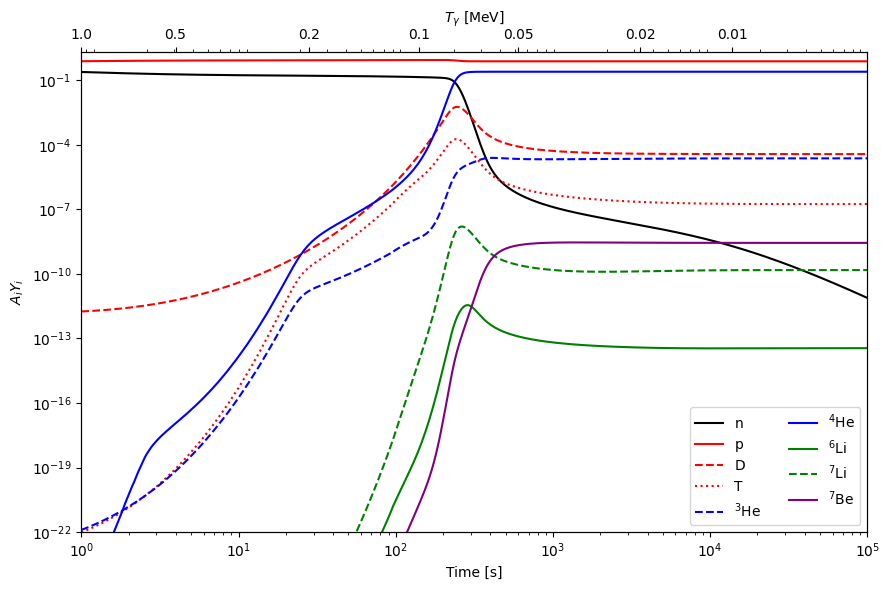

In [6]:
species_medium = [
    ('n',   'black',  'solid',   'n'),
    ('p',   'red',    'solid',   'p'),
    ('H2',  'red',    'dashed',  'D'),
    ('H3',  'red',    'dotted',  'T'),
    ('He3', 'blue',   'dashed',  r'$^3$He'),
    ('He4', 'blue',   'solid',   r'$^4$He'),
    ('Li6', 'green',  'solid',   r'$^6$Li'),
    ('Li7', 'green',  'dashed',  r'$^7$Li'),
    ('Be7', 'purple', 'solid',   r'$^7$Be'),
]

fig, ax = plt.subplots(figsize=(9, 6))
for name, color, ls, label in species_medium:
    vals = r_medium.A[name] * r_medium[name](t)
    mask = vals > 0
    if mask.any():
        ax.plot(t[mask], vals[mask], color=color, ls=ls, label=label)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Time [s]'); ax.set_ylabel(r'$A_i Y_i$')
ax.set_xlim(1, 1e5); ax.set_ylim(1e-22, 2)
ax.legend(ncol=2); add_temperature_axis(ax, r_medium, T_ticks_MeV)
plt.tight_layout(); plt.show()

## Large network (~433 reactions, ~59 nuclides)

Every tracked nuclide is plotted.  The light elements match the medium network;
the heavy-nuclide tail is approximate (limited by the AC2024 rate floors).  Lower
`atol_large_LT` (default `1e-25`) to resolve smaller abundances at extra cost.

In [7]:
r_large = PyPR({'network': 'large', 'verbose': True})
# To resolve tinier nuclides, e.g.: PyPR({'network':'large','atol_large_LT':1e-30})


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 ┃
┃   ░█▀█░█░█░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀              ┃
┃   ░█▀▀░░█░░█▀▀░█▀▄░░█░░█░█░█▀█░░█░              ┃
┃   ░▀░░░░▀░░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░              ┃
┃                                                 ┃
┃    Welcome to PyPRIMAT v0.1.0 — Cyril Pitrou    ┃
┃                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[init]  numba detected: using it for JIT compilation.
[init]  Electron-thermo tables loaded from cache (2000 points).
[init]  Tables loaded.
[rates] Building 'large' network from text lists.
[rates] MT network: 17 reactions over 12 nuclides.
[rates] LT network: 425 reactions over 59 nuclides.
------------------------------------------------------------
Loaded 426 reactions (LT network):
------------------------------------------------------------
  n <-> p                           [weak n<->p]
  B10 + He3 <-> C11 + H2      

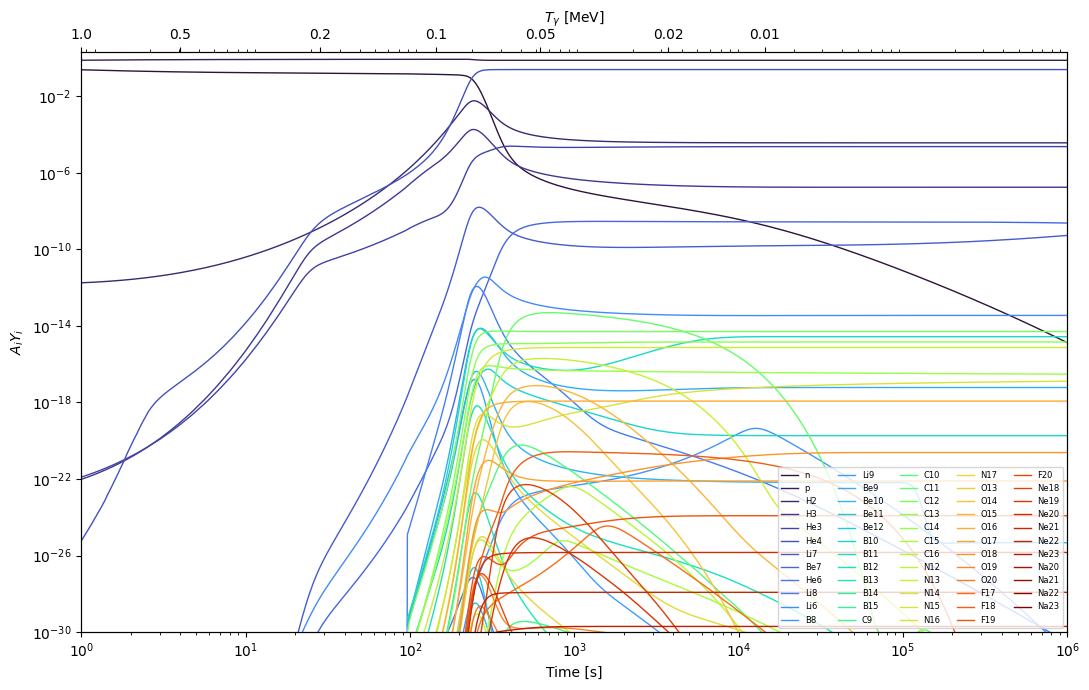

In [9]:
import matplotlib.cm as cm

names = r_large.abundance_names               # all ~59 tracked nuclides
colors = cm.turbo(np.linspace(0, 1, len(names)))

fig, ax = plt.subplots(figsize=(11, 7))
for name, c in zip(names, colors):
    vals = r_large.A[name] * r_large[name](t)
    mask = vals > 0
    if mask.any():
        ax.plot(t[mask], vals[mask], color=c, lw=1.0, label=name)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Time [s]'); ax.set_ylabel(r'$A_i Y_i$')
ax.set_xlim(1, 1e6); ax.set_ylim(1e-30, 2)
ax.legend(ncol=5, fontsize=6, loc='lower right')
add_temperature_axis(ax, r_large, T_ticks_MeV)
plt.tight_layout(); plt.show()